# Important Libraries

In [524]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder , StandardScaler
import numpy as np
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Load Both Dataset 

Train dataset load

In [410]:
df_train =pd.read_csv("train.csv")

C:\Users\INTEL\AppData\Local\Temp\ipykernel_7472\1617190613.py:1: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train =pd.read_csv("train.csv")


Test dataset load

In [411]:
df_test = pd.read_csv("test.csv")

# Train Dataset

In [412]:
# see first 5 rows
df_train.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [413]:
# see the last 5 rows
df_train.tail()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
99995,0x25fe9,CUS_0x942c,April,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,_,502.38,34.663572,31 Years and 6 Months,No,35.104023,60.97133255718485,High_spent_Large_value_payments,479.866228,Poor
99996,0x25fea,CUS_0x942c,May,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,_,502.38,40.565631,31 Years and 7 Months,No,35.104023,54.18595028760385,High_spent_Medium_value_payments,496.65161,Poor
99997,0x25feb,CUS_0x942c,June,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,Good,502.38,41.255522,31 Years and 8 Months,No,35.104023,24.02847744864441,High_spent_Large_value_payments,516.809083,Poor
99998,0x25fec,CUS_0x942c,July,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,Good,502.38,33.638208,31 Years and 9 Months,No,35.104023,251.67258219721603,Low_spent_Large_value_payments,319.164979,Standard
99999,0x25fed,CUS_0x942c,August,Nicks,25,078-73-5990,Mechanic,39628.99_,3359.415833,4,...,Good,502.38,34.192463,31 Years and 10 Months,No,35.104023,167.1638651610451,!@9#%8,393.673696,Poor


In [414]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

 In the train dataset , there are almost 28 columns where 4 float , 4 int and rest of them are object 

In [415]:
df_train.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


In [416]:
df_train.shape

(100000, 28)

In [417]:
df_train.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

#  Exploratory Data Analysis for Train dataset

In [418]:
# drop unnecessary columns
df_train = df_train.drop(['ID','Customer_ID','Month','SSN','Name'], axis=1)

In [419]:
df_train.isnull().sum()

Age                             0
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary       15002
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Type_of_Loan                11408
Delay_from_due_date             0
Num_of_Delayed_Payment       7002
Changed_Credit_Limit            0
Num_Credit_Inquiries         1965
Credit_Mix                      0
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Credit_History_Age           9030
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly      4479
Payment_Behaviour               0
Monthly_Balance              1200
Credit_Score                    0
dtype: int64

# Handling missing values

In [420]:
df_train["Age"] = df_train["Age"].astype(str).str.replace("_", "", regex=False)

In [421]:
df_train["Age"] = pd.to_numeric(df_train["Age"], errors="coerce")

In [422]:
df_train["Age"] = pd.to_numeric(df_train["Age"], errors="coerce")

In [423]:
df_train["Age"] = df_train["Age"].fillna(df_train["Age"].median())

In [424]:
df_train['Monthly_Inhand_Salary'] = df_train['Monthly_Inhand_Salary'].fillna(df_train['Monthly_Inhand_Salary'].mean())

In [425]:
df_train['Type_of_Loan'] = df_train['Type_of_Loan'].fillna(df_train['Type_of_Loan'].mode()[0])

In [426]:
df_train['Num_of_Delayed_Payment'] = df_train['Num_of_Delayed_Payment'].fillna(df_train['Num_of_Delayed_Payment'].mode()[0])

In [427]:
df_train['Num_Credit_Inquiries']= df_train['Num_Credit_Inquiries'].fillna(df_train['Num_Credit_Inquiries'].std())

In [428]:
import re
import numpy as np

def convert_to_months(x):
    if pd.isna(x):
        return np.nan

    match = re.search(r'(\d+)\s+Years?\s+and\s+(\d+)\s+Months?', str(x))
    if match:
        years = int(match.group(1))
        months = int(match.group(2))
        return years * 12 + months

    return np.nan

df_train["Credit_History_Age"] = df_train["Credit_History_Age"].apply(convert_to_months)

In [429]:
df_train["Credit_History_Age"] = df_train["Credit_History_Age"].fillna(df_train["Credit_History_Age"].median())

In [430]:
df_train["Amount_invested_monthly"] = df_train["Amount_invested_monthly"].replace("--100--", 100)

In [431]:
df_train['Amount_invested_monthly']= df_train['Amount_invested_monthly'].fillna(df_train['Amount_invested_monthly'].mode()[0])

In [432]:
df_train["Monthly_Balance"] = pd.to_numeric(df_train["Monthly_Balance"],errors="coerce")
df_train['Monthly_Balance'] = df_train['Monthly_Balance'].fillna(df_train['Monthly_Balance'].median())

In [433]:
df_train['Credit_History_Age'] = df_train['Credit_History_Age'].fillna(df_train['Credit_History_Age'].mean())

In [434]:
df_train.isnull().sum()

Age                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
dtype: int64

Finally handling the nan values on the train dataset

In [435]:
df_train.duplicated().sum()

np.int64(0)

# Test Dataset

In [436]:
df_test.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,0x160a,CUS_0xd40,September,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,2022.0,Good,809.98,35.030402,22 Years and 9 Months,No,49.574949,236.64268203272135,Low_spent_Small_value_payments,186.26670208571772
1,0x160b,CUS_0xd40,October,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.053114,22 Years and 10 Months,No,49.574949,21.465380264657146,High_spent_Medium_value_payments,361.44400385378196
2,0x160c,CUS_0xd40,November,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.811894,NaN,No,49.574949,148.23393788500925,Low_spent_Medium_value_payments,264.67544623342997
3,0x160d,CUS_0xd40,December,Aaron Maashoh,24_,821-00-0265,Scientist,19114.12,NaN,3,...,4.0,Good,809.98,32.430559,23 Years and 0 Months,No,49.574949,39.08251089460281,High_spent_Medium_value_payments,343.82687322383634
4,0x1616,CUS_0x21b1,September,Rick Rothackerj,28,004-07-5839,_______,34847.84,3037.986667,2,...,5.0,Good,605.03,25.926822,27 Years and 3 Months,No,18.816215,39.684018417945296,High_spent_Large_value_payments,485.2984336755923


In [437]:
df_test.tail()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
49995,0x25fe5,CUS_0x8600,December,Sarah McBridec,4975,031-35-0942,Architect,20002.88,1929.906667,10,...,12.0,_,3571.7,34.780553,NaN,Yes,60.964772,146.48632477751087,Low_spent_Small_value_payments,275.53956951573343
49996,0x25fee,CUS_0x942c,September,Nicks,25,078-73-5990,Mechanic,39628.99,NaN,4,...,7.0,Good,502.38,27.758522,31 Years and 11 Months,NM,35.104023,181.44299902757518,Low_spent_Small_value_payments,409.39456169535066
49997,0x25fef,CUS_0x942c,October,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,7.0,Good,502.38,36.858542,32 Years and 0 Months,No,35.104023,__10000__,Low_spent_Large_value_payments,349.7263321025098
49998,0x25ff0,CUS_0x942c,November,Nicks,25,078-73-5990,Mechanic,39628.99,NaN,4,...,7.0,Good,502.38,39.139840,32 Years and 1 Months,No,35.104023,97.59857973344877,High_spent_Small_value_payments,463.23898098947717
49999,0x25ff1,CUS_0x942c,December,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,7.0,_,502.38,34.108530,32 Years and 2 Months,No,35.104023,220.45787812168732,Low_spent_Medium_value_payments,360.37968260123847


In [438]:
df_test.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance'],
      dtype='object')

In [439]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        50000 non-null  object 
 1   Customer_ID               50000 non-null  object 
 2   Month                     50000 non-null  object 
 3   Name                      44985 non-null  object 
 4   Age                       50000 non-null  object 
 5   SSN                       50000 non-null  object 
 6   Occupation                50000 non-null  object 
 7   Annual_Income             50000 non-null  object 
 8   Monthly_Inhand_Salary     42502 non-null  float64
 9   Num_Bank_Accounts         50000 non-null  int64  
 10  Num_Credit_Card           50000 non-null  int64  
 11  Interest_Rate             50000 non-null  int64  
 12  Num_of_Loan               50000 non-null  object 
 13  Type_of_Loan              44296 non-null  object 
 14  Delay_

There are almost 27 columns where float are 4 and int are 4 and rest of them are object type data type

In [440]:
df_test.describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly_Inhand_Salary,42502.0,4182.004291,3174.109304,303.645417,1625.188333,3086.305000,5934.189094,15204.633333
Num_Bank_Accounts,50000.0,16.838260,116.396848,-1.000000,3.000000,6.000000,7.000000,1798.000000
Num_Credit_Card,50000.0,22.921480,129.314804,0.000000,4.000000,5.000000,7.000000,1499.000000
Interest_Rate,50000.0,68.772640,451.602363,1.000000,8.000000,13.000000,20.000000,5799.000000
Delay_from_due_date,50000.0,21.052640,14.860397,-5.000000,10.000000,18.000000,28.000000,67.000000
Num_Credit_Inquiries,48965.0,30.080200,196.984121,0.000000,4.000000,7.000000,10.000000,2593.000000
Credit_Utilization_Ratio,50000.0,32.279581,5.106238,20.509652,28.061040,32.280390,36.468591,48.540663
Total_EMI_per_month,50000.0,1491.304305,8595.647887,0.000000,32.222388,74.733349,176.157491,82398.000000


In [441]:
df_test.shape

(50000, 27)

In [442]:
df_test.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance'],
      dtype='object')

#  Exploratory Data Analysis for Test dataset

In [443]:
# drop unnecessary columns
df_test = df_test.drop(['ID','Customer_ID','Month','SSN','Name'], axis=1)

In [444]:
df_test.isnull().sum()

Age                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary       7498
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                5704
Delay_from_due_date            0
Num_of_Delayed_Payment      3498
Changed_Credit_Limit           0
Num_Credit_Inquiries        1035
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age          4470
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     2271
Payment_Behaviour              0
Monthly_Balance              562
dtype: int64

# Handling missing values

In [445]:
df_test['Age'].unique()[:60]

array(['23', '24', '24_', '28', '35', '55', '22', '31', '32', '1694',
       '34', '30', '914', '45', '41_', '41', '33', '36', '39', '40',
       '40_', '37', '21', '46', '26', '27', '32_', '42', '42_', '20',
       '48', '49', '33_', '38', '38_', '44', '-500', '16', '17', '37_',
       '19_', '19', '3193', '43', '339', '14', '15', '25', '21_', '1203',
       '46_', '2823', '22_', '18', '47', '1643', '20_', '35_', '8327_',
       '29'], dtype=object)

In [446]:
df_test["Age"] = df_test["Age"].astype(str).str.replace("_", "", regex=False)

In [447]:
df_test["Age"] = pd.to_numeric(df_test["Age"], errors="coerce")

In [448]:
df_test["Age"] = df_test["Age"].fillna(df_test["Age"].median())

In [449]:
df_test['Monthly_Inhand_Salary'] = df_test['Monthly_Inhand_Salary'].fillna(df_test['Monthly_Inhand_Salary'].mean())

In [450]:
df_test['Type_of_Loan'] = df_test['Type_of_Loan'].fillna(df_test['Type_of_Loan'].mode()[0])

In [451]:
import re
import numpy as np

def convert_to_months(x):
    if pd.isna(x):
        return np.nan

    match = re.search(r'(\d+)\s+Years?\s+and\s+(\d+)\s+Months?', str(x))
    if match:
        years = int(match.group(1))
        months = int(match.group(2))
        return years * 12 + months

    return np.nan

df_test["Credit_History_Age"] = df_test["Credit_History_Age"].apply(convert_to_months)

In [452]:
df_test["Credit_History_Age"] = df_test["Credit_History_Age"].fillna(df_test["Credit_History_Age"].median())

In [453]:
df_test['Num_of_Delayed_Payment'] = df_test['Num_of_Delayed_Payment'].fillna(df_test['Num_of_Delayed_Payment'].mode()[0])

In [454]:
df_test['Num_Credit_Inquiries'] =df_test['Num_Credit_Inquiries'].fillna(df_test['Num_Credit_Inquiries'].mean())

In [455]:
df_test["Amount_invested_monthly"] = df_test["Amount_invested_monthly"].replace("--100--", 100)

In [456]:
df_test['Amount_invested_monthly']= df_test['Amount_invested_monthly'].fillna(df_test['Amount_invested_monthly'].mode()[0])

In [457]:
df_test["Monthly_Balance"] = pd.to_numeric(df_test["Monthly_Balance"],errors="coerce")
df_test['Monthly_Balance'] = df_test['Monthly_Balance'].fillna(df_test['Monthly_Balance'].median())

In [458]:
df_test.isna().sum()

Age                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
dtype: int64

Handling All missing values 

In [459]:
# Check Duplicate values for test values
df_test.duplicated().sum()

np.int64(0)

In [460]:
from sklearn.preprocessing import LabelEncoder

object_cols = df_train.select_dtypes(include=['object']).columns.drop('Credit_Score')

encoders = {}

for col in object_cols:
    le = LabelEncoder()

    combined = pd.concat([
        df_train[col].astype(str),
        df_test[col].astype(str)
    ])

    le.fit(combined)

    df_train[col] = le.transform(df_train[col].astype(str))
    df_test[col] = le.transform(df_test[col].astype(str))

    encoders[col] = le

In [461]:
target_encoder = LabelEncoder()
df_train['Credit_Score'] = target_encoder.fit_transform(df_train['Credit_Score'])

# **Dataset spliting and Performing Encoding and Scalling for Train dataset**

In [462]:
x =df_train.drop(['Credit_Score'],axis=1)
y = df_train['Credit_Score']

# Performing Train Test Split

In [463]:
xtrain , xtest , ytrain , ytest = train_test_split(x,y, test_size=.25, random_state=42)

Here 
0 -> Good
1 -> Poor
2 -> Standard

# **Apply Decision tree classifire**

In [ ]:
dt = DecisionTreeClassifier(criterion='entropy', max_depth=40,min_samples_split=50,min_samples_leaf=10,max_features='sqrt',random_state=42)

#Training Score
model_dt = dt.fit(xtrain,ytrain)
print("Training score : ", model_dt.score(xtrain,ytrain)*100)

# Test Score
print("Test score : ", model_dt.score(xtest,ytest)*100)

#Prediction
dt_prediction =dt.predict(xtest)

Training score :  75.52
Test score :  68.60000000000001


## **Model Evaluation**

Accuracy Score :  69.02000000000001
Classificatio Report :                precision    recall  f1-score   support

           0       0.60      0.59      0.59      4422
           1       0.68      0.66      0.67      7313
           2       0.73      0.74      0.73     13265

    accuracy                           0.69     25000
   macro avg       0.67      0.66      0.66     25000
weighted avg       0.69      0.69      0.69     25000



<Axes: >

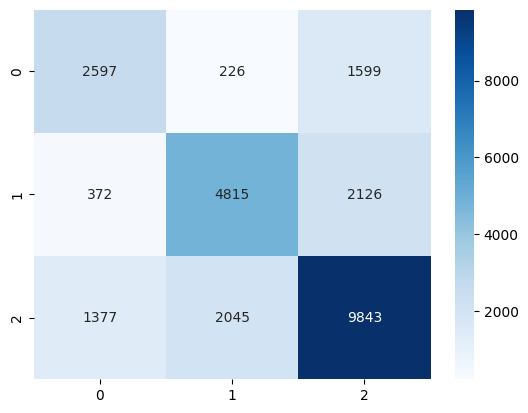

In [512]:
# Accuracy Score
accScore_dt = accuracy_score(ytest,dt_prediction)
print("Accuracy Score : ",accScore_dt*100)

#Confusion Matrix

class_max =classification_report(ytest,dt_prediction)
print("Classificatio Report : ", class_max)

# Confusion Matrix
con_max = confusion_matrix(ytest, dt_prediction)
sns.heatmap(con_max,annot=True,fmt='d',cmap="Blues")


In [500]:
final_prediction = dt.predict(df_test)

##  **Performing Random Forest perform model and Evaluation**

In [523]:
rf = RandomForestClassifier(n_estimators=700,max_depth=50,min_samples_split=10,min_samples_leaf=2,max_features='|',bootstrap=True,random_state=42,n_jobs=-1)


#Training Score
model_rf = dt.fit(xtrain,ytrain)
print("Training score : ", model_rf.score(xtrain,ytrain)*100)

# Test Score
print("Test score : ", model_rf.score(xtest,ytest)*100)

#Prediction
dt_prediction =dt.predict(xtest)

Training score :  75.52
Test score :  68.60000000000001
